In [40]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [41]:
mpl.rcParams['font.family'] = 'Nimbus Roman'
plt.rcParams['font.size'] = 15

In [5]:
history = pd.read_hdf("/home/ew640340/Ph.D./Foundation_Models/train_val_history.h5", key="df")

In [10]:
train_loss = history['train_total']
val_loss = history['val_total']
epochs = np.arange(1, len(train_loss) + 1)

In [34]:
def five_epoch_average(loss_values):
    return np.convolve(loss_values, np.ones(5)/5, mode='valid')

x_five_epoch = epochs[2:-2]  # Adjust x-axis for the 5-epoch average

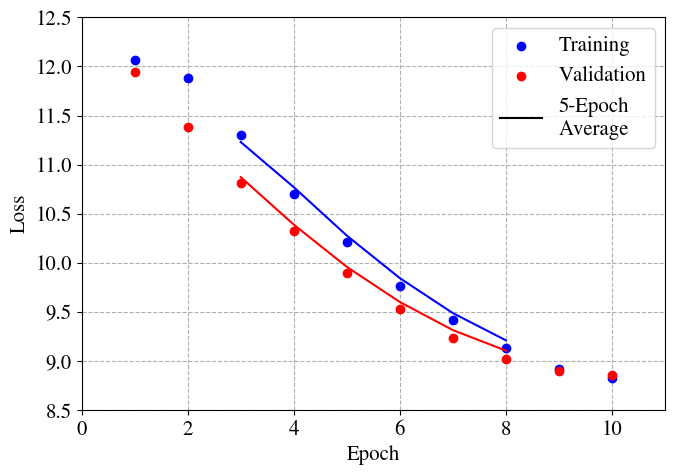

In [42]:
fig1, ax1 = plt.subplots(figsize=(7,5), dpi=100)
ax1.scatter(epochs, train_loss, label='Training', color="blue", marker="o")
ax1.plot(x_five_epoch, five_epoch_average(train_loss), color="blue")
ax1.scatter(epochs, val_loss, label='Validation', color="red", marker="o")
ax1.plot(x_five_epoch, five_epoch_average(val_loss), color="red")

ax1.plot(-1,-1, color="black", label="5-Epoch\nAverage")

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_xlim(0, len(train_loss) + 1)
ax1.set_ylim(8.5,12.5)
ax1.legend(loc="upper right")
ax1.grid(linestyle="--")
ax1.set_axisbelow(True)
plt.tight_layout()
plt.show()

